In [ ]:
! pip install tensorflow

In [ ]:
# importing libraries for deep learning
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

https://www.kaggle.com/datasets/thedevastator/bank-term-deposit-predictions

In [ ]:
df = pd.read_csv("train.csv")
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


In [ ]:
import pandas as pd

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")


1 - age (numeric)
2 - job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student", "blue-collar","self-employed","retired","technician","services")
3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)
4 - education (categorical: "unknown","secondary","primary","tertiary")
5 - default: has credit in default? (binary: "yes","no")
6 - balance: average yearly balance, in euros (numeric)
7 - housing: has housing loan? (binary: "yes","no")
8 - loan: has personal loan? (binary: "yes","no")
related with the last contact of the current campaign:
9 - contact: contact communication type (categorical: "unknown","telephone","cellular")
10 - day: last contact day of the month (numeric)
11 - month: last contact month of year (categorical: "jan", "feb", "mar", …, "nov", "dec")
12 - duration: last contact duration, in seconds (numeric)
other attributes:
13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)
15 - previous: number of contacts performed before this campaign and for this client (numeric)
16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")
Output variable (desired target):

17 - y - has the client subscribed a term deposit? (binary: "yes","no")

In [ ]:
train_df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


In [ ]:
test_df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no


In [ ]:

# Combine
full_df = pd.concat([train_df, test_df], ignore_index=True)
full_df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49727,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
49728,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
49729,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
49730,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no


In [ ]:
full_df.drop('duration', axis = 1,inplace = True)

In [ ]:
full_df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous',
       'poutcome', 'y'],
      dtype='object')

In [ ]:
full_df['y'].value_counts()

,count
y,
no,43922
yes,5810


In [ ]:
# Encoded the target variables
full_df['y'] = full_df['y'].map({'yes':1, "no":0})

In [ ]:
# input and output x,y
x = full_df.drop('y',axis =1)
y = full_df['y']

In [ ]:
#Encoding for categorical columns
categorical_cols = x.select_dtypes(include=['object']).columns

In [ ]:
x = pd.get_dummies(x, columns = categorical_cols, drop_first = True)

In [ ]:
x

,age,balance,day,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,job_management,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,58,2143,5,1,-1,0,False,False,False,True,...,False,False,False,True,False,False,False,False,False,True
1,44,29,5,1,-1,0,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,33,2,5,1,-1,0,False,True,False,False,...,False,False,False,True,False,False,False,False,False,True
3,47,1506,5,1,-1,0,True,False,False,False,...,False,False,False,True,False,False,False,False,False,True
4,33,1,5,1,-1,0,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49727,33,-333,30,5,-1,0,False,False,False,False,...,True,False,False,False,False,False,False,False,False,True
49728,57,-3313,9,1,-1,0,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
49729,57,295,19,11,-1,0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
49730,28,1137,6,4,211,3,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [ ]:
# Feature Scaling
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [ ]:
x_train, x_test,y_train,y_test= train_test_split(x_scaled, y, test_size=0.2,random_state= 42)

In [ ]:
model = Sequential()
model.add(Dense(32,activation = 'relu', input_dim = x_train.shape[1]))
model.add(Dense(16, activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


model = Sequential()

Sequential means your model is a stack of layers in order.

Data flows forward from one layer to the next (no branching).

Good for simple feed-forward neural networks.

2. model.add(Dense(32, activation='relu', input_dim=x_train.shape[1]))

Dense layer = fully connected layer (every input neuron connects to every output neuron).

32 → number of neurons in this hidden layer.

activation='relu' → applies ReLU function:


This introduces non-linearity and helps the network learn complex patterns.

input_dim=x_train.shape[1] → number of features (columns) in your dataset. This tells the model the shape of input.

Input → Hidden Layer (32 neurons, ReLU) → Hidden Layer (16 neurons, ReLU) → Output Layer (1 neuron, Sigmoid).

This is a 3-layer feedforward neural network for binary classification.

In [ ]:
# compiling the model
model.compile(loss = "binary_crossentropy", optimizer='SGD', metrics = ['accuracy'])

In [ ]:
'''Compile the model ---setting the strategy for learning
1)loss Function -- this gives an idea about the error in the model
2)Optimizer---control how the weight updated during back propogation
3) metric---- what should be reported during the training phase
'''

In [ ]:
# training the model
history = model.fit(x_train,y_train,validation_split=0.1,epochs=25,batch_size = 32, verbose=1)

Epoch 1/25
1119/1119 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8694 - loss: 0.4244 - val_accuracy: 0.8872 - val_loss: 0.3228
Epoch 2/25
1119/1119 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8851 - loss: 0.3247 - val_accuracy: 0.8914 - val_loss: 0.3053
Epoch 3/25
1119/1119 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8915 - loss: 0.3086 - val_accuracy: 0.8924 - val_loss: 0.3007
Epoch 4/25
1119/1119 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8933 - loss: 0.3040 - val_accuracy: 0.8912 - val_loss: 0.2983
Epoch 5/25
1119/1119 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8894 - loss: 0.3090 - val_accuracy: 0.8902 - val_loss: 0.2967
Epoch 6/25
1119/1119 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8902 - loss: 0.3080 - val_accuracy: 0.8909 - val_loss: 0.2951
Epoch 7/25
1119/1119 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8939 - loss: 0.2983 - val_accuracy: 0.8917 - val_loss: 0.2942
Epoch 8/25
1119/1119 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8935 - loss: 0.2992 - 

In [ ]:
'''
-- validation_split=0.1

Reserves 10% of training data as validation set (not used in training, but used to check model performance after each epoch).

Helps detect overfitting.

--epochs=50

Epoch = one complete pass through the entire training dataset.

So the model will see all training samples 50 times.

-- batch_size=32

Data is broken into mini-batches of 32 samples.

Weights are updated after each batch (instead of after the whole dataset).

Makes training faster + helps generalization.

--
verbose=1

Controls the training output:

0 → silent.

1 → progress bar + metrics (most common).

2 → one line per epoch.

--
history = ...

The fit method returns a History object.

history.history contains metrics recorded during training:

loss, accuracy, val_loss, val_accuracy.

You can use it to plot training curves.


Training the model for 50 epochs with batches of 32 samples, keeping 10% aside for validation, and saving training history for later analysis.'''

In [ ]:
# plots
import matplotlib.pyplot as plt
import seaborn as sns

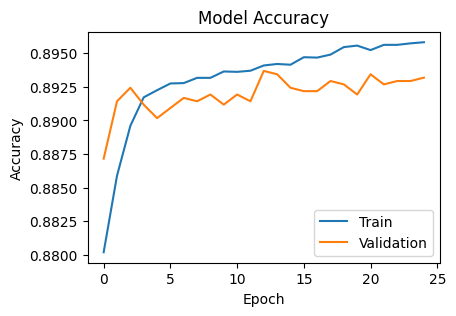

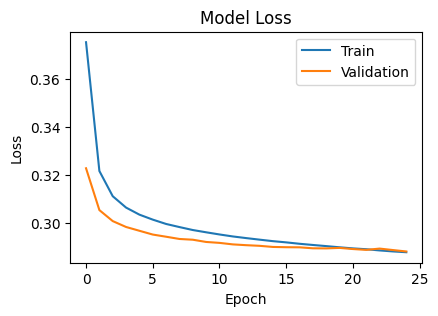

In [ ]:
plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])


plt.figure(figsize=(10,3))
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()